In [ ]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# Load model
model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

# -------------------------
# IMAGE
# -------------------------

image = Image.open("/content/1me (4).jpeg")

image_inputs = processor(
    images=image,
    return_tensors="pt"
)

with torch.no_grad():

    vision_outputs = model.vision_model(
        pixel_values=image_inputs["pixel_values"]
    )

    print(vision_outputs)

    image_embedding = vision_outputs.pooler_output

    print(image_embedding)



    image_embedding = model.visual_projection(
        image_embedding
    )

# Normalize
image_embedding = image_embedding / image_embedding.norm(
    dim=-1,
    keepdim=True
)


# -------------------------
# TEXT
# -------------------------

texts = [
    "a dog playing",
    "a red sports car",
    "a pizza",
    "a cat"
]

text_inputs = processor(
    text=texts,
    return_tensors="pt",
    padding=True
)

with torch.no_grad():

    text_outputs = model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"]
    )

    text_embeddings = text_outputs.pooler_output

    text_embeddings = model.text_projection(
        text_embeddings
    )

# Normalize
text_embeddings = text_embeddings / text_embeddings.norm(
    dim=-1,
    keepdim=True
)


# -------------------------
# SIMILARITY
# -------------------------

similarities = text_embeddings @ image_embedding.T

for text, score in zip(texts, similarities):
    print(f"{text}: {score.item():.4f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.2669,  0.2001, -0.1809,  ...,  0.1538, -0.2428,  0.1468],
         [ 0.2647, -0.0034,  0.0976,  ..., -0.2884,  0.6591,  0.4051],
         [ 0.3389, -0.0889, -0.1339,  ..., -0.1870,  0.4221,  0.4951],
         ...,
         [-0.4617,  0.2432, -0.1342,  ...,  0.1189,  0.5418,  0.4333],
         [-0.2648,  0.4000,  0.1744,  ...,  0.1949,  0.4237,  0.4258],
         [-0.5884,  0.4618,  0.3259,  ...,  0.1142,  0.6882,  0.7527]]]), pooler_output=tensor([[ 1.3147e+00,  5.0328e-01, -5.8683e-01,  1.5774e+00,  7.5536e-02,
         -1.8284e-01, -6.2222e-01, -1.1514e+00,  1.8460e+00,  7.2573e-01,
          2.3399e-01,  1.1850e+00,  5.3314e-01,  5.2989e-01,  4.1048e-01,
          3.3711e-02, -1.5207e+00, -1.0588e-01,  4.1184e-01,  2.8257e-02,
         -9.2270e-02,  8.3778e-01,  1.0151e+00, -1.8380e-01, -5.5513e-01,
          1.0470e+00, -3.5839e-01, -3.9281e-01, -9.5425e-01,  1.7199e+00,
         -2.8115e+00, -1.6705e+00,  9.4036e-01, -1.039

In [ ]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

# Input text
text = "Multimodal AI is amazing!"

# Tokenize
tokens = tokenizer(
    text,
    return_tensors="pt"
)

print("Input Text:")
print(text)

print("\nTokens:")
print(tokenizer.tokenize(text))

print("\nToken IDs:")
print(tokens["input_ids"])

print("\nAttention Mask:")
print(tokens["attention_mask"])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Input Text:
Multimodal AI is amazing!

Tokens:
['multi', '##mo', '##dal', 'ai', 'is', 'amazing', '!']

Token IDs:
tensor([[ 101, 4800, 5302, 9305, 9932, 2003, 6429,  999,  102]])

Attention Mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])


Original image size:
(960, 1280)

Processed tensor shape:
torch.Size([3, 224, 224])


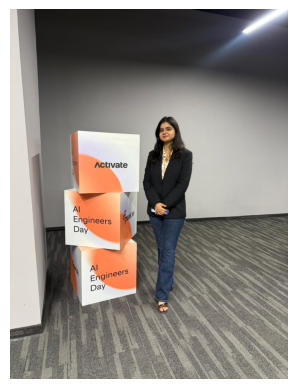

In [ ]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Load image
image = Image.open("/content/1me (4).jpeg")

print("Original image size:")
print(image.size)

# Define preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Process image
image_tensor = transform(image)

print("\nProcessed tensor shape:")
print(image_tensor.shape)

# Display image
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
from torchvision import transforms

image = Image.open("/content/1me (4).jpeg")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_tensor = transform(image)

print(image_tensor.shape)

torch.Size([3, 224, 224])


Audio shape: (480000,)
Sample rate: 16000


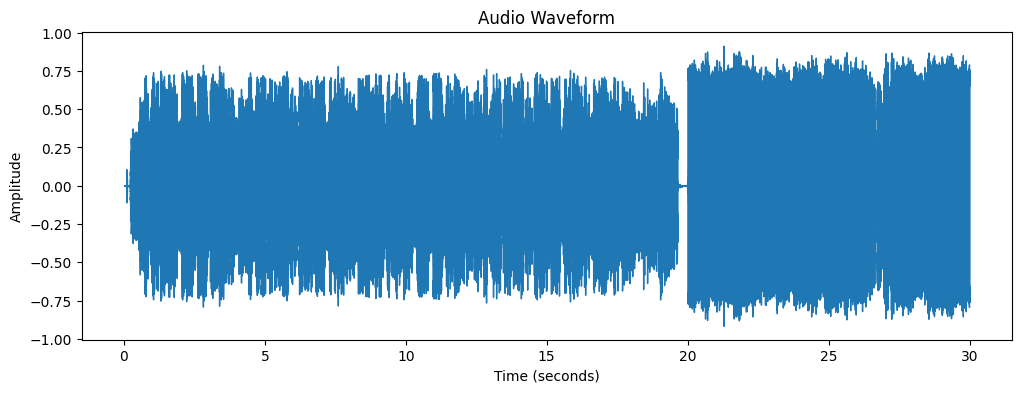

[[9.1471629e-28 3.2761837e-03 1.9729412e-01 ... 5.2523766e+01
  1.9193727e+01 2.2241039e+01]
 [5.8365546e-27 5.6550168e-03 5.3126067e-01 ... 1.6691443e+02
  1.5010866e+02 1.5109795e+02]
 [1.3677808e-26 7.7309082e-03 2.1014550e+00 ... 1.1366580e+02
  1.5748598e+02 1.3358774e+02]
 ...
 [1.7936890e-27 7.6401653e-07 4.9273069e-05 ... 8.2201578e-02
  6.5495498e-02 4.0155519e-02]
 [3.0252741e-27 6.2987021e-07 4.9901468e-05 ... 3.5259161e-02
  3.3448823e-02 1.8269625e-02]
 [9.5631483e-28 1.8327940e-08 1.0849855e-06 ... 1.6462872e-03
  1.3322763e-03 2.5739213e-03]]


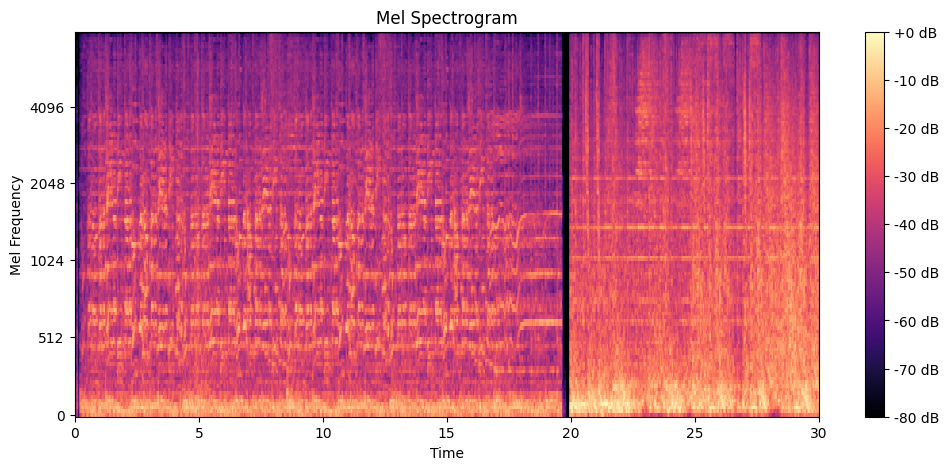

In [ ]:
!pip install -q librosa

# Imports
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Load Audio
# --------------------------------------------------

audio, sample_rate = librosa.load(
    "/content/dhumtanana_serial.mp3",
    sr=16000
)

print("Audio shape:", audio.shape)
print("Sample rate:", sample_rate)


# --------------------------------------------------
# 2. Visualize Waveform
# --------------------------------------------------

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sample_rate
)

plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()


# --------------------------------------------------
# 3. Generate Mel Spectrogram
# --------------------------------------------------

spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sample_rate
)

print(spectrogram)


# --------------------------------------------------
# 4. Convert Power Spectrogram to Decibels
# --------------------------------------------------

log_spectrogram = librosa.power_to_db(
    spectrogram,
    ref=np.max
)


# --------------------------------------------------
# 5. Visualize Mel Spectrogram
# --------------------------------------------------

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    log_spectrogram,
    sr=sample_rate,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

actual = [
    "dog",
    "cat",
    "car",
    "dog",
    "car"
]

predicted = [
    "dog",
    "cat",
    "car",
    "cat",
    "car"
]

accuracy = accuracy_score(
    actual,
    predicted
)

print("Accuracy:", accuracy)

Accuracy: 0.8


In [ ]:
from sklearn.metrics import accuracy_score

actual = [
    "dog",
    "cat",
    "car",
    "dog",
    "car"
]

predicted = [
    "dog",
    "cat",
    "car",
    "cat",
    "car"
]

accuracy = accuracy_score(
    actual,
    predicted
)

print("Accuracy:", accuracy)

Accuracy: 0.8


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

actual = [
    "dog",
    "cat",
    "car",
    "dog",
    "car"
]

predicted = [
    "dog",
    "cat",
    "car",
    "cat",
    "car"
]

print(
    "Precision:",
    precision_score(
        actual,
        predicted,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        actual,
        predicted,
        average="weighted"
    )
)

print(
    "F1:",
    f1_score(
        actual,
        predicted,
        average="weighted"
    )
)

Precision: 0.9
Recall: 0.8
F1: 0.8


[[1 1 0]
 [0 1 0]
 [0 0 2]]


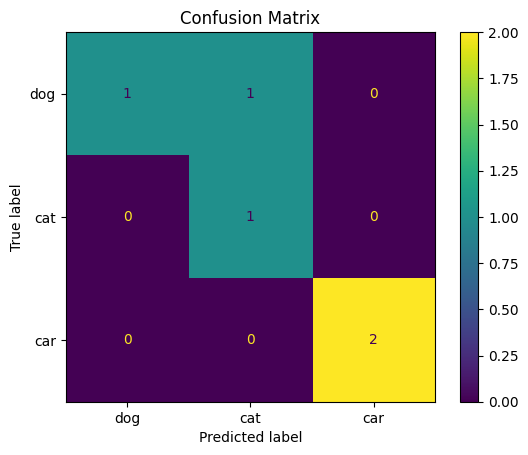

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

actual = [
    "dog",
    "cat",
    "car",
    "dog",
    "car"
]

predicted = [
    "dog",
    "cat",
    "car",
    "cat",
    "car"
]

cm = confusion_matrix(
    actual,
    predicted,
    labels=["dog", "cat", "car"]
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["dog", "cat", "car"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()